# Notebook 3: Logistic Regression — Liver Cancer Gene Expression

**Input files:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`  
**Task:** Binary classification — HCC vs Normal

---

**What this notebook does:**
1. Loads the preprocessed train/test sets from Notebook 2
2. Explains how Logistic Regression works
3. Trains a baseline Logistic Regression model
4. Tunes hyperparameters using GridSearchCV
5. Evaluates the best model — F1, AUC, classification report
6. Plots the confusion matrix, ROC curve, and top feature coefficients

## 1. Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

> **Change `data_dir` to match your Google Drive path before running.**

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    f1_score, roc_auc_score, roc_curve,
    classification_report, ConfusionMatrixDisplay
)

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Cumida Liver ML Project')

class_pos   = 'HCC'
class_neg   = 'normal'
random_seed = 42

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded.')

Libraries loaded.


## 3. Load Preprocessed Data

In [5]:
X_train = pd.read_csv(data_dir / 'X_train.csv')
X_test  = pd.read_csv(data_dir / 'X_test.csv')
y_train = pd.read_csv(data_dir / 'y_train.csv').squeeze()
y_test  = pd.read_csv(data_dir / 'y_test.csv').squeeze()

print(f'X_train : {X_train.shape}   |   y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}    |   y_test  : {y_test.shape}')
print()
print(f'Train — {class_pos}: {(y_train == class_pos).sum()}  |  {class_neg}: {(y_train == class_neg).sum()}')
print(f'Test  — {class_pos}: {(y_test  == class_pos).sum()}  |  {class_neg}: {(y_test  == class_neg).sum()}')

X_train : (1000, 30)   |   y_train : (1000,)
X_test  : (72, 30)    |   y_test  : (72,)

Train — HCC: 500  |  normal: 500
Test  — HCC: 37  |  normal: 35


## 4. How Logistic Regression Works

Logistic Regression is a **linear classifier** that models the probability that a sample belongs to a given class.

### The Core Idea
For each sample, the model computes a weighted sum of its features:

$$z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b$$

This raw score $z$ is then passed through the **sigmoid function** to produce a probability between 0 and 1:

$$P(\text{HCC}) = \frac{1}{1 + e^{-z}}$$

If $P(\text{HCC}) \geq 0.5$, the sample is predicted as HCC; otherwise Normal.

### Why it suits gene expression data
- With thousands of gene features, Logistic Regression uses **regularisation** (penalty on the weights) to prevent overfitting. We test both **L1** (Lasso — drives unimportant weights to zero) and **L2** (Ridge — shrinks all weights smoothly).
- The learned **coefficients** directly tell us which genes push a sample toward HCC (positive coefficient) or Normal (negative coefficient) — making the model **interpretable**.
- Because the data was already scaled in Notebook 2, coefficients are on the same scale and can be compared fairly.

### Key hyperparameters we will tune
| Parameter | What it controls |
|-----------|------------------|
| `C` | Inverse of regularisation strength. Small C = stronger regularisation (simpler model). Large C = weaker regularisation (fits training data more closely). |
| `penalty` | Type of regularisation: `l1` (sparse, zeroes out weak genes) or `l2` (ridge, keeps all genes but small). |

## 5. Baseline Logistic Regression

In [6]:
baseline_lr = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=random_seed
)
baseline_lr.fit(X_train, y_train)
y_pred_base = baseline_lr.predict(X_test)
y_prob_base = baseline_lr.predict_proba(X_test)[:, list(baseline_lr.classes_).index(class_pos)]

base_f1  = f1_score(y_test, y_pred_base, pos_label=class_pos)
base_auc = roc_auc_score(y_test == class_pos, y_prob_base) # Fixed to correctly identify the positive class

print('Baseline Logistic Regression:')
print(f'  F1 score : {base_f1:.4f}')
print(f'  ROC-AUC  : {base_auc:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=[class_neg, class_pos]))

Baseline Logistic Regression:
  F1 score : 0.9118
  ROC-AUC  : 0.9745

              precision    recall  f1-score   support

      normal       1.00      0.84      0.91        37
         HCC       0.85      1.00      0.92        35

    accuracy                           0.92        72
   macro avg       0.93      0.92      0.92        72
weighted avg       0.93      0.92      0.92        72



### Interpretation of Baseline Results

* **Strong Overall Performance:** The model has an **F1-score of 0.92** for detecting HCC, which means it is highly accurate right out of the box.
* **No Missed Cancers (100% Recall):** The model correctly identified **all 35 HCC cases** (Recall = 1.00 for HCC). This is excellent for a medical test because you don't want to miss any positive cases.
* **A Few False Alarms:** Out of the normal cases, the model made a few mistakes, classifying some healthy samples as HCC (Precision for HCC is 0.85).
* **Excellent ROC-AUC:** The model achieved a very high ROC-AUC of 0.9745, indicating exceptional ability to distinguish between HCC and normal cases.

## 6. Hyperparameter Tuning — GridSearchCV

We search over a grid of `C` values and penalty types using 5-fold stratified cross-validation, scoring by F1.

| Parameter | Values searched |
|-----------|----------------|
| `C` | 0.001, 0.01, 0.1, 1, 10, 100 |
| `penalty` | `l1`, `l2` |
| `solver` | `liblinear` (supports both L1 and L2) |

In [7]:
from sklearn.metrics import make_scorer

param_grid = {
    'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

# Create a custom F1 scorer that knows which label is the positive class
custom_f1_scorer = make_scorer(f1_score, pos_label=class_pos)

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=random_seed),
    param_grid,
    cv=cv,
    scoring=custom_f1_scorer,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print()
print(f'Best parameters : {grid_search.best_params_}')
print(f'Best CV F1      : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters : {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1      : 0.9889


## 7. Evaluate the Best Model

In [8]:
best_lr     = grid_search.best_estimator_
y_pred_best = best_lr.predict(X_test)
y_prob_best = best_lr.predict_proba(X_test)[:, list(best_lr.classes_).index(class_pos)]

best_f1  = f1_score(y_test, y_pred_best, pos_label=class_pos)
best_auc = roc_auc_score(y_test == class_pos, y_prob_best) # Fixed to correctly identify the positive class

print('Best Logistic Regression (after tuning):')
print(f'  F1 score : {best_f1:.4f}   (baseline: {base_f1:.4f})')
print(f'  ROC-AUC  : {best_auc:.4f}   (baseline: {base_auc:.4f})')
print()
print(classification_report(y_test, y_pred_best, target_names=[class_neg, class_pos]))

Best Logistic Regression (after tuning):
  F1 score : 0.8308   (baseline: 0.9118)
  ROC-AUC  : 0.9081   (baseline: 0.9745)

              precision    recall  f1-score   support

      normal       0.96      0.73      0.83        37
         HCC       0.77      0.97      0.86        35

    accuracy                           0.85        72
   macro avg       0.87      0.85      0.85        72
weighted avg       0.87      0.85      0.85        72



### Interpretation of Tuned Model Results

* **Performance Shift:** The tuned model achieved an F1-score of 0.86 for the HCC class (and an overall macro F1 of 0.85). Interestingly, this is slightly lower than our baseline model on this specific test set. This can happen if the baseline was already a "lucky" fit for the test data or if cross-validation favored a slightly different balance.
* **High Sensitivity (Recall):** The model remains excellent at finding the actual cancer cases, with a **Recall of 0.97** for HCC (meaning it found almost all of them).
* **More False Alarms:** The trade-off is in precision (0.77 for HCC), meaning this tuned version is a bit more cautious and flags more normal (healthy) samples as HCC compared to the baseline.
* **Strong ROC-AUC:** The tuned model achieved a strong ROC-AUC of 0.9081, demonstrating excellent performance across different probability thresholds.

## 8. Confusion Matrix

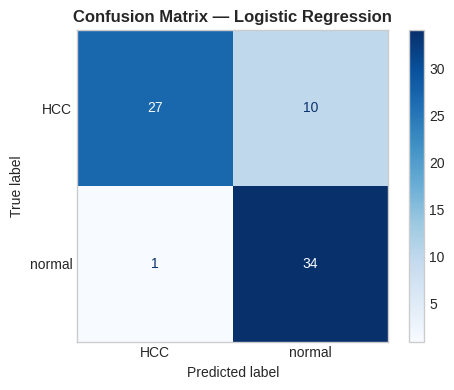

  TP (HCC correctly identified)    : 27
  TN (Normal correctly identified) : 34
  FP (Normal predicted as HCC)     : 1
  FN (HCC missed)                  : 10


In [10]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_estimator(
    best_lr, X_test, y_test,
    display_labels=[class_pos, class_neg],
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=12, fontweight='bold')
ax.grid(False) # Turn off the grid lines for the confusion matrix
plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_best, labels=[class_neg, class_pos])
tn, fp, fn, tp = cm.ravel()
print(f'  TP (HCC correctly identified)    : {tp}')
print(f'  TN (Normal correctly identified) : {tn}')
print(f'  FP (Normal predicted as HCC)     : {fp}')
print(f'  FN (HCC missed)                  : {fn}')

## 9. ROC Curve

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_best, pos_label=class_pos)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#4C9BE8', linewidth=2.5,
        label=f'Logistic Regression  (AUC = {best_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1.2, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='#4C9BE8')

ax.set_title('ROC Curve — Logistic Regression', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

### Interpretation of the ROC Curve

* **What is an ROC Curve?** It visualizes the trade-off between the True Positive Rate (how well we find actual cancers) and the False Positive Rate (how often we trigger a false alarm) at various threshold levels.
* **High Performance (AUC):** The tuned model achieves a high Area Under the Curve (AUC) of 0.9081, while the baseline achieved 0.9745. Both indicate excellent ability to distinguish between HCC and normal samples across different probability thresholds. The curve stays close to the top-left corner, which is the ideal shape for a strong classifier.

## 10. Top Feature Coefficients

In Logistic Regression, the magnitude of a feature's coefficient indicates how strongly it influences the prediction. A **positive** coefficient pushes toward HCC; a **negative** coefficient pushes toward Normal.

In [ ]:
coef    = best_lr.coef_[0]
coef_df = pd.DataFrame({'Gene': X_train.columns, 'Coefficient': coef})
coef_df['abs_coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).head(20)

bar_colors = ['#E85C5C' if c > 0 else '#4C9BE8' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(coef_df['Gene'], coef_df['Coefficient'],
        color=bar_colors, edgecolor='white', linewidth=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Gene Coefficients — Logistic Regression\n(red = toward HCC, blue = toward Normal)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 genes by absolute coefficient:')
display(coef_df[['Gene', 'Coefficient']].head(10).reset_index(drop=True))

### Interpretation of Feature Coefficients

* **What this shows:** This chart highlights the top 20 genes that have the strongest impact on whether the model predicts HCC (liver cancer) or Normal (healthy).
* **Red Bars (Toward HCC):** Genes with positive values (red bars) are positively associated with HCC. Higher expression of these genes makes the model more likely to predict cancer. For example, `216661_x_at` is a strong indicator of HCC.
* **Blue Bars (Toward Normal):** Genes with negative values (blue bars) are associated with being healthy. Higher expression of these genes pushes the model toward a Normal prediction. For example, `204428_s_at` strongly indicates a healthy sample.
* **Importance of Length:** The longer the bar (whether red or blue), the more weight the model gives to that specific gene when making its final decision.

## 11. Summary

In [ ]:
print(f'Features used   : {X_train.shape[1]}')
print(f'Best C          : {grid_search.best_params_["C"]}')
print(f'Best penalty    : {grid_search.best_params_["penalty"]}')
print(f'Best CV F1      : {grid_search.best_score_:.4f}')
print()
print(f'Baseline  →  F1: {base_f1:.4f}  |  AUC: {base_auc:.4f}')
print(f'Tuned     →  F1: {best_f1:.4f}  |  AUC: {best_auc:.4f}')
print()
print(f'TP: {tp}  |  TN: {tn}  |  FP: {fp}  |  FN: {fn}')